In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
from model.resnet_cifar10_manual import resnet20
import matplotlib.pyplot as plt
import numpy as np
import timm
import detectors

device = ("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


/home/hr15h1k35h/Desktop/SNOWS/venv/lib/python3.13/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Using device: cuda


In [2]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
test_dataset = datasets.CIFAR10(root="./datasets", train=False, download=True,transform=test_transform)
test_dataset_unnorm = datasets.CIFAR10(root="./datasets", train=False, download=True)


In [3]:
image, label = test_dataset[0]
print(test_dataset.classes[label])

cat


In [4]:
image_unnorm, label_unnorm = test_dataset_unnorm[0]
print(test_dataset_unnorm.classes[label_unnorm])

cat


In [5]:
pruned1_4resnet20_path = torch.load("./Pruned_models/resnet20_cifar10_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet20_path = torch.load("./Pruned_models/resnet20_cifar10_SNOWS_2:4_k=40_model.pth", map_location=device)


In [6]:

pruned1_4resnet20 = resnet20()
pruned2_4resnet20 = resnet20()

pruned1_4resnet20.load_state_dict(pruned1_4resnet20_path)
pruned2_4resnet20.load_state_dict(pruned2_4resnet20_path)

pruned1_4resnet20.eval()
pruned2_4resnet20.eval()


ResNetCifar(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [7]:
original_resnet20_dict = torch.load('./checkpoints/resnet20_cifar10.pt', map_location=device)
original_resnet20 = resnet20()

original_resnet20.load_state_dict(original_resnet20_dict)
original_resnet20.eval()

ResNetCifar(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU()
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU()
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [8]:
image = image.unsqueeze(0).to(device)


In [9]:
original_resnet20.to(device)
pruned1_4resnet20.to(device)
pruned2_4resnet20.to(device)

with torch.no_grad():
    output_original = original_resnet20(image)
    output1_4 = pruned1_4resnet20(image)
    output2_4 = pruned2_4resnet20(image)

# predicted_probabilities = torch.nn.functional.softmax(output)
output_class_orig = torch.argmax(output_original, dim=1).item()
output_class_1_4 = torch.argmax(output1_4, dim=1).item()
output_class_2_4 = torch.argmax(output2_4, dim=1).item()

output_class_orig_probs = F.softmax(output_original, dim = 1)
output_class_1_4_probs = F.softmax(output1_4, dim=1)
output_class_2_4_probs = F.softmax(output2_4, dim=1)

In [10]:
label

3

In [11]:
test_dataset.classes[label]

'cat'

In [12]:
output1_4

tensor([[-2.3370, -2.4152, -0.8477,  7.1874, -2.1214,  6.7605,  1.5433, -1.4048,
         -3.0127, -3.3527]], device='cuda:0')

Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet20 \n cat(1.0)')

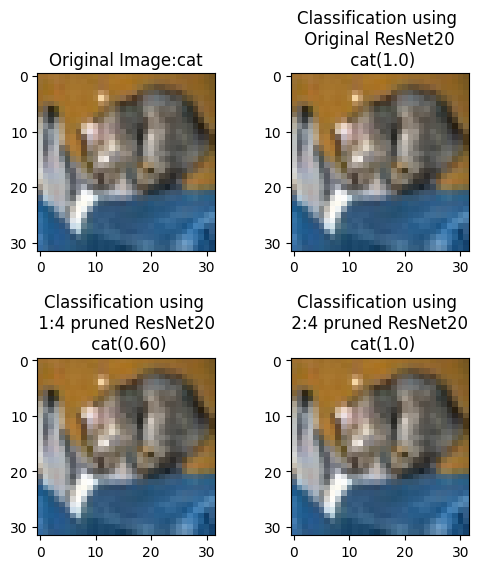

In [13]:
fig, axes = plt.subplots(2, 2, figsize = (6, 6))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.6)
axes[0, 0].imshow(image_unnorm)
axes[0, 0].set_title(f"Original Image:{test_dataset.classes[label]}")


axes[0, 1].imshow(image_unnorm)
axes[0, 1].set_title(f"Classification using \n Original ResNet20 \n {test_dataset.classes[output_class_orig]}({output_class_orig_probs[0, output_class_orig].item()})")

axes[1, 0].imshow(image_unnorm)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet20 \n {test_dataset.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image_unnorm)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet20 \n {test_dataset.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item()})")


In [14]:
original_resnet50 = timm.create_model("resnet50_cifar10", pretrained=True)
original_resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [15]:
image_02, label_02 = test_dataset[3]
print(test_dataset.classes[label_02])

airplane


In [16]:
image_unnorm, label_unnorm = test_dataset_unnorm[3]

In [17]:
pruned1_4resnet50_path = torch.load("./Pruned_models/resnet50_cifar10_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet50_path = torch.load("./Pruned_models/resnet50_cifar10_SNOWS_2:4_k=40_model.pth", map_location=device)

In [18]:
pruned2_4resnet50 = timm.create_model("resnet50_cifar10", pretrained=False)
pruned1_4resnet50 = timm.create_model("resnet50_cifar10", pretrained=False)

pruned1_4resnet50.load_state_dict(pruned1_4resnet50_path)
pruned2_4resnet50.load_state_dict(pruned2_4resnet50_path)

pruned1_4resnet50.eval()
pruned2_4resnet50.eval()



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [19]:
original_resnet50.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [20]:
image_02 = image_02.unsqueeze(0).to(device)

In [21]:
original_resnet50.to(device)
pruned1_4resnet50.to(device)
pruned2_4resnet50.to(device)

with torch.no_grad():
    output_class_orig = original_resnet50(image_02)
    output1_4 = pruned1_4resnet50(image_02)
    output2_4 = pruned2_4resnet50(image_02)

output_class_orig = torch.argmax(output_original, dim=1).item()
output_class_1_4 = torch.argmax(output1_4, dim=1).item()
output_class_2_4 = torch.argmax(output2_4, dim=1).item()

output_class_orig_probs = F.softmax(output_original, dim = 1)
output_class_1_4_probs = F.softmax(output1_4, dim=1)
output_class_2_4_probs = F.softmax(output2_4, dim=1)


Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet50 \n airplane(0.99)')

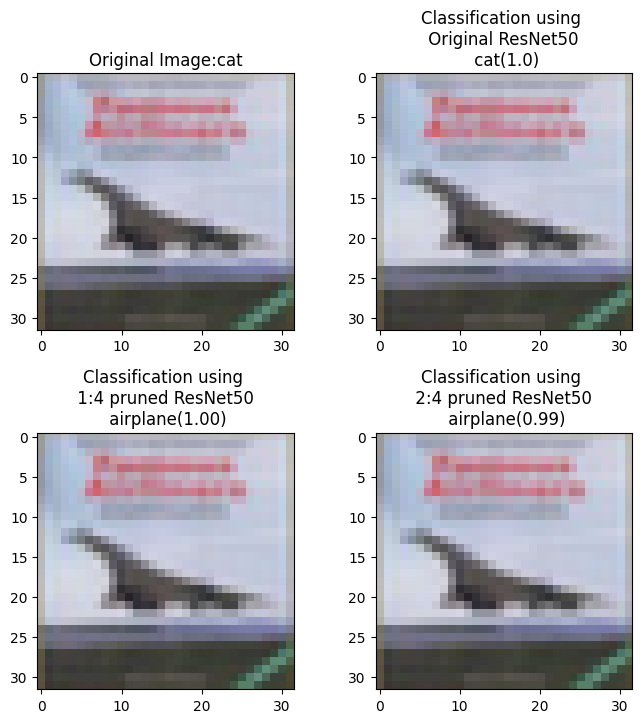

In [22]:
fig, axes = plt.subplots(2, 2, figsize = (8, 8))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.4)
axes[0, 0].imshow(image_unnorm)
axes[0, 0].set_title(f"Original Image:{test_dataset.classes[label]}")


axes[0, 1].imshow(image_unnorm)
axes[0, 1].set_title(f"Classification using \n Original ResNet50 \n {test_dataset.classes[output_class_orig]}({output_class_orig_probs[0, output_class_orig].item()})")

axes[1, 0].imshow(image_unnorm)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet50 \n {test_dataset.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image_unnorm)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet50 \n {test_dataset.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item():.2f})")


In [23]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
test_dataset = datasets.CIFAR100(root="./datasets", train=False, download=True,transform=test_transform)
test_dataset_unnorm = datasets.CIFAR100(root="./datasets", train=False, download=True)


In [24]:
image_03, label_03 = test_dataset[0]
print(test_dataset.classes[label_03])

mountain


In [25]:
image_unnorm, label_unnorm = test_dataset_unnorm[0]
print(test_dataset_unnorm.classes[label_unnorm])

mountain


In [26]:
pruned1_4resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_1:4_k=40_model.pth", map_location=device)
pruned2_4resnet50c100_path = torch.load("./Pruned_models/resnet50_cifar100_SNOWS_2:4_k=40_model.pth", map_location=device)

In [27]:
pruned1_4resnet50 = timm.create_model("resnet50_cifar100", pretrained=False)
pruned2_4resnet50 = timm.create_model("resnet50_cifar100", pretrained=False)

pruned1_4resnet50.load_state_dict(pruned1_4resnet50c100_path)
pruned2_4resnet50.load_state_dict(pruned2_4resnet50c100_path)

pruned1_4resnet50.eval()
pruned2_4resnet50.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [28]:
original_resnet50c100 = timm.create_model("resnet50_cifar100", pretrained=True)
original_resnet50.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act3): ReLU(inplace=True)
      (downsample): Sequential(
    

In [29]:
image_03 = image_03.unsqueeze(0).to(device)

In [30]:
original_resnet50.to(device)
pruned1_4resnet50.to(device)
pruned2_4resnet50.to(device)

with torch.no_grad():
    output_class_orig = original_resnet50(image_02)
    output1_4 = pruned1_4resnet50(image_02)
    output2_4 = pruned2_4resnet50(image_02)

output_class_orig = torch.argmax(output_original, dim=1).item()
output_class_1_4 = torch.argmax(output1_4, dim=1).item()
output_class_2_4 = torch.argmax(output2_4, dim=1).item()

output_class_orig_probs = F.softmax(output_original, dim = 1)
output_class_1_4_probs = F.softmax(output1_4, dim=1)
output_class_2_4_probs = F.softmax(output2_4, dim=1)


Text(0.5, 1.0, 'Classification using \n 2:4 pruned ResNet50 \n otter(0.25)')

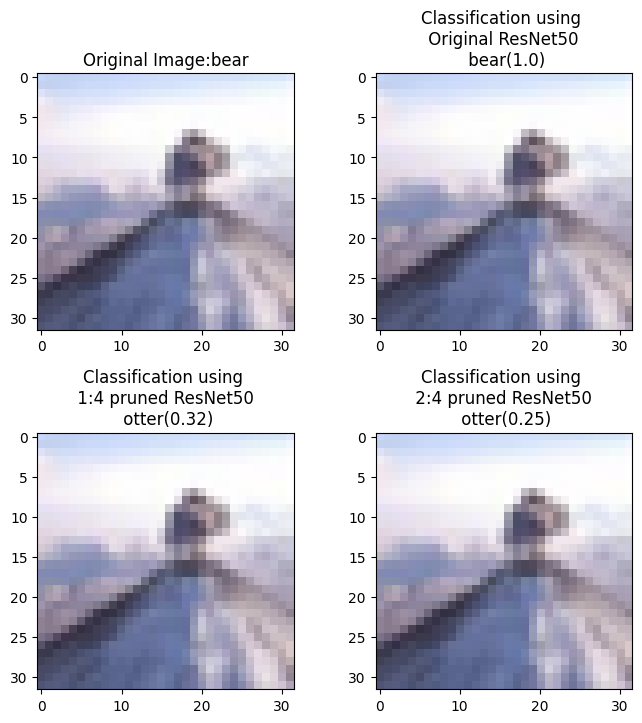

In [31]:
fig, axes = plt.subplots(2, 2, figsize = (8, 8))
# original_img = image.permute(1, 2, 0)
plt.subplots_adjust(hspace=0.4)
axes[0, 0].imshow(image_unnorm)
axes[0, 0].set_title(f"Original Image:{test_dataset.classes[label]}")


axes[0, 1].imshow(image_unnorm)
axes[0, 1].set_title(f"Classification using \n Original ResNet50 \n {test_dataset.classes[output_class_orig]}({output_class_orig_probs[0, output_class_orig].item()})")

axes[1, 0].imshow(image_unnorm)
axes[1, 0].set_title(f"Classification using \n 1:4 pruned ResNet50 \n {test_dataset.classes[output_class_1_4]}({output_class_1_4_probs[0, output_class_1_4].item():.2f})")


axes[1, 1].imshow(image_unnorm)
axes[1, 1].set_title(f"Classification using \n 2:4 pruned ResNet50 \n {test_dataset.classes[output_class_2_4]}({output_class_2_4_probs[0, output_class_2_4].item():.2f})")
